In [8]:
# Instalación de utilidades necesarias para entornos gráficos
!apt-get install x11-utils > /dev/null 2>&1
!pip install pyglet > /dev/null 2>&1
!apt-get install -y xvfb python-opengl > /dev/null 2>&1

# Importación de bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

# Listado de entornos disponibles en Gym
from gym import envs
all_envs = envs.registry.all()
env_ids = [env_spec.id for env_spec in all_envs]
print(sorted(env_ids))


['Acrobot-v1', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'Blackjack-v1', 'CarRacing-v2', 'CartPole-v0', 'CartPole-v1', 'CliffWalking-v0', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Humanoid-v2', 'Humanoid-v3', 'Humanoid-v4', 'HumanoidStandup-v2', 'HumanoidStandup-v4', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'LunarLander-v2', 'LunarLanderContinuous-v2', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Pusher-v2', 'Pusher-v4', 'Reacher-v2', 'Reacher-v4', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Taxi-v3', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4']


/usr/local/lib/python3.11/dist-packages/gym/envs/registration.py:421: UserWarning: WARN: The `registry.all` method is deprecated. Please use `registry.values` instead.
  logger.warn(


In [9]:
import gym
env = gym.make('Pendulum-v1').env

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [10]:
print('State space', env.observation_space)
print('Action space', env.action_space)

State space Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space Box(-2.0, 2.0, (1,), float32)


In [11]:
import imageio

In [12]:
nb_actions = env.action_space

In [13]:
nb_obs = env.observation_space

In [14]:
from collections import deque

In [15]:
class DQNAgent:
    def __init__(self):
        self.state_dim      = 3
        self.action_dim     = 9
        self.lr             = 0.001
        self.gamma          = 0.98
        self.tau            = 0.01
        self.epsilon        = 1.0
        self.epsilon_decay  = 0.995
        self.epsilon_min    = 0.001
        self.buffer_size    = 100000
        self.batch_size     = 64
        self.memory         = ReplayBuffer(self.buffer_size)

        self.Q              = QNetwork(self.state_dim, self.action_dim, self.lr)
        self.Q_target       = QNetwork(self.state_dim, self.action_dim, self.lr)
        self.Q_target.load_state_dict(self.Q.state_dict())

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            # Exploración: elige una acción aleatoria
            return np.random.randint(self.action_dim)
        else:
            # Explotación: elige la mejor acción según la red
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.Q(state_tensor)
            return torch.argmax(q_values).item()
        
    def discretize_action(self, action_index):
        # Discretiza el espacio continuo de acciones [-2, 2]
        action_space = np.linspace(-2, 2, self.action_dim)
        return np.array([action_space[action_index]])

    def train(self):
        if self.memory.size() < self.batch_size:
            return  # No entrenamos hasta que haya suficientes muestras
    
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
    
        # Calculamos Q objetivo
        target_q = rewards + self.gamma * self.Q_target(next_states).max(1, keepdim=True)[0] * (1 - dones)
        
        # Calculamos Q actual
        current_q = self.Q(states).gather(1, actions)
    
        # Calculamos la pérdida
        loss = nn.MSELoss()(current_q, target_q.detach())
    
        # Optimizamos la red
        self.Q.optimizer.zero_grad()
        loss.backward()
        self.Q.optimizer.step()
    
        # Actualización suave de la red objetivo
        for target_param, param in zip(self.Q_target.parameters(), self.Q.parameters()):
            target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)
    
        # Decaimiento del epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay



In [16]:
class ReplayBuffer:
    def __init__(self, buffer_limit):
        self.buffer = deque(maxlen=buffer_limit)

    def put(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        mini_batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*mini_batch)
        return (torch.tensor(states, dtype=torch.float32),
                torch.tensor(actions, dtype=torch.int64).unsqueeze(1),
                torch.tensor(rewards, dtype=torch.float32).unsqueeze(1),
                torch.tensor(next_states, dtype=torch.float32),
                torch.tensor(dones, dtype=torch.float32).unsqueeze(1))

    def size(self):
        return len(self.buffer)


In [17]:
!pip install --upgrade typing-extensions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.13.2
    Uninstalling typing_extensions-4.13.2:
      Successfully uninstalled typing_extensions-4.13.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.3.2 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.0.0 which is incompatible.
langchain-core 0.3.50 requires packaging<25,>=23.2, but you have packaging 25.0 which is incompatible.
bigframes 1.42.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.

In [18]:
import torch.nn as nn
import torch

In [24]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, q_lr):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc_out = nn.Linear(64, action_dim)
        self.optimizer = optim.Adam(self.parameters(), lr=q_lr)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc_out(x)

In [20]:
import torch.optim as optim

In [25]:
agent = DQNAgent()

In [26]:
import random

agent = DQNAgent()
num_episodes = 1000  # Puedes ajustarlo
rewards_per_episode = []

for episode in range(num_episodes):
    state = env.reset()
    episode_reward = 0

    for step in range(200):  # Cada episodio tiene máximo 200 pasos
        action_index = agent.select_action(state)
        action = agent.discretize_action(action_index)

        next_state, reward, done, _ = env.step(action)
        
        # Almacenamos la experiencia en el buffer
        agent.memory.put((state, action_index, reward, next_state, done))
        
        state = next_state
        episode_reward += reward

        # Entrenamos el agente
        agent.train()

        rewards_per_episode.append(episode_reward)
        

        if done:
            break

    # Mostramos información cada 10 episodios
    if episode % 10 == 0:
        print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {agent.epsilon:.3f}")

print("Entrenamiento completado")


Episode 0, Reward: -1306.43, Epsilon: 0.503
Episode 10, Reward: -903.85, Epsilon: 0.001
Episode 20, Reward: -1.47, Epsilon: 0.001
Episode 30, Reward: -246.48, Epsilon: 0.001
Episode 40, Reward: -238.75, Epsilon: 0.001
Episode 50, Reward: -232.35, Epsilon: 0.001
Episode 60, Reward: -244.22, Epsilon: 0.001
Episode 70, Reward: -120.15, Epsilon: 0.001
Episode 80, Reward: -250.99, Epsilon: 0.001
Episode 90, Reward: -231.75, Epsilon: 0.001
Episode 100, Reward: -127.21, Epsilon: 0.001
Episode 110, Reward: -116.80, Epsilon: 0.001
Episode 120, Reward: -237.87, Epsilon: 0.001
Episode 130, Reward: -3.45, Epsilon: 0.001
Episode 140, Reward: -121.63, Epsilon: 0.001
Episode 150, Reward: -126.03, Epsilon: 0.001
Episode 160, Reward: -356.89, Epsilon: 0.001
Episode 170, Reward: -1.04, Epsilon: 0.001
Episode 180, Reward: -126.10, Epsilon: 0.001
Episode 190, Reward: -245.79, Epsilon: 0.001
Episode 200, Reward: -128.53, Epsilon: 0.001
Episode 210, Reward: -117.62, Epsilon: 0.001
Episode 220, Reward: -116.

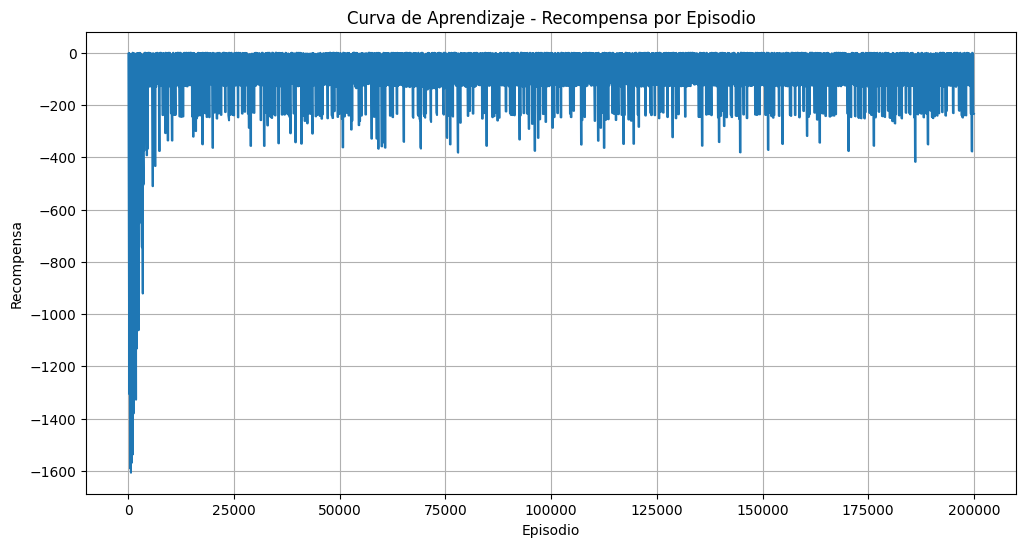

In [27]:
import matplotlib.pyplot as plt

# Ahora graficamos:
plt.figure(figsize=(12, 6))
plt.plot(rewards_per_episode)
plt.xlabel('Episodio')
plt.ylabel('Recompensa')
plt.title('Curva de Aprendizaje - Recompensa por Episodio')
plt.grid()
plt.show()

Recompensa total del episodio de prueba: -126.74


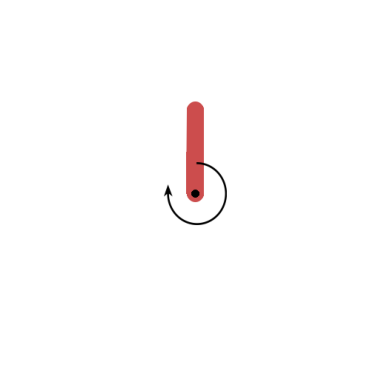

In [28]:
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

# Reiniciamos el entorno
state = env.reset()

# Simulamos un episodio de prueba (sin exploración)
done = False
total_reward = 0

for step in range(200):
    # El agente ya no explora, solo actúa según lo aprendido
    action_index = agent.select_action(state)
    action = agent.discretize_action(action_index)

    next_state, reward, done, _ = env.step(action)
    total_reward += reward

    # Renderizamos el entorno
    frame = env.render(mode='rgb_array')
    plt.imshow(frame)
    plt.axis('off')
    ipythondisplay.clear_output(wait=True)
    ipythondisplay.display(plt.gcf())

    state = next_state

    if done:
        break

ipythondisplay.clear_output(wait=True)
env.close()

print(f"Recompensa total del episodio de prueba: {total_reward:.2f}")
